# Threshold calibration — delegation clustering + model routing

**Issue:** [#140](https://github.com/frederick-douglas-pearce/agentfluent/issues/140)

Both `agentfluent.diagnostics.delegation` (#110) and
`agentfluent.diagnostics.model_routing` (#111) shipped with threshold
constants informed by backlog guidance, not empirical data. This
notebook validates those defaults against real agent session data
from `~/.claude/projects/`.

## ⚠️ Limitations

- **Single-developer dataset.** The calibration here is based on one
  contributor's session history. Real-world usage patterns across
  different domains (web dev, data science, infrastructure work)
  could easily justify different thresholds. Treat these as informed
  starting points, not settled defaults. Re-run this notebook when
  contributors with representative data can add projects.
- **One run per moment in time.** Thresholds don't need weekly
  re-tuning. Re-run when: (a) feature code changes that affect
  threshold semantics, (b) new contributors add project data, or
  (c) observed false-positive / false-negative rates climb.

## Coverage

15 thresholds across both modules:

**Delegation** — `MIN_TEXT_TOKENS`, `LSA_COMPONENTS`,
`DEFAULT_MIN_CLUSTER_SIZE`, `DEFAULT_MIN_SIMILARITY`,
`_SILHOUETTE_K_MAX`, `_CONFIDENCE_HIGH_SIZE`,
`_CONFIDENCE_HIGH_COHESION`, `_CONFIDENCE_MEDIUM_COHESION`,
`_HEAVY_TOKEN_THRESHOLD`

**Model routing** — `_MIN_INVOCATIONS_FOR_ANALYSIS`,
`_SIMPLE_MAX_TOOL_CALLS`, `_SIMPLE_MAX_TOKENS`,
`_COMPLEX_MIN_TOOL_CALLS`, `_COMPLEX_MIN_TOKENS`,
`_COMPLEX_MIN_ERROR_RATE`

## Setup

Point this at any Claude Code config directory. Defaults to
``~/.claude/`` (the standard location) if the ``CLAUDE_CONFIG_DIR``
environment variable isn't set. To analyze a different dataset
(e.g., a colleague's shared projects), either edit the ``config_dir``
value in the cell below or export the env var before launching
Jupyter::

    export CLAUDE_CONFIG_DIR=/path/to/other/.claude
    uv run jupyter lab scripts/calibration/threshold_validation.ipynb


In [1]:
from __future__ import annotations

import os
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from agentfluent.analytics.pipeline import analyze_sessions
from agentfluent.core.discovery import discover_projects
from agentfluent.core.paths import projects_dir_for
from agentfluent.diagnostics.delegation import (
    MIN_TEXT_TOKENS,
    cluster_delegations,
)
from agentfluent.diagnostics.model_routing import (
    classify_complexity,
    aggregate_agent_stats,
)
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100
pd.options.display.max_rows = 20
pd.options.display.float_format = "{:.2f}".format

# Override via CLAUDE_CONFIG_DIR env var, or edit this line directly.
# `None` => default `~/.claude/` location.
config_dir: Path | None = (
    Path(os.environ["CLAUDE_CONFIG_DIR"])
    if "CLAUDE_CONFIG_DIR" in os.environ
    else None
)
# `projects_dir_for(None)` returns None; `discover_projects(base_path=None)`
# then falls back to the default `~/.claude/projects/` location.
projects_root = projects_dir_for(config_dir)
from agentfluent.core.discovery import DEFAULT_PROJECTS_DIR
effective_root = projects_root if projects_root is not None else DEFAULT_PROJECTS_DIR
print(f"Analyzing projects under: {effective_root}")

Analyzing projects under: /home/fdpearce/.claude/projects


## Load all sessions

In [2]:
projects = list(discover_projects(base_path=projects_root))
print(f"Projects: {len(projects)}")

all_invocations = []
for p in projects:
    paths = [s.path for s in p.sessions]
    result = analyze_sessions(paths)
    for s in result.sessions:
        all_invocations.extend(s.invocations)

print(f"Total invocations: {len(all_invocations)}")

Projects: 7


Malformed JSON at a0e5f523-1191-45ca-97ba-3b40c64f57c0.jsonl:662


Malformed JSON at 14ddceb0-4c3b-4194-be1c-060c019303cd.jsonl:129


Malformed JSON at 14ddceb0-4c3b-4194-be1c-060c019303cd.jsonl:228


Total invocations: 320


In [3]:
df_inv = pd.DataFrame([
    {
        "agent_type": inv.agent_type,
        "total_tokens": inv.total_tokens,
        "tool_uses": inv.tool_uses,
        "duration_ms": inv.duration_ms,
        "has_trace": inv.trace is not None,
        "trace_model": inv.trace.model if inv.trace is not None else None,
        "description_tokens": len(inv.description.split()),
        "prompt_tokens": len(inv.prompt.split()),
        "combined_tokens": len((inv.description + " " + inv.prompt).split()),
    }
    for inv in all_invocations
])
df_inv.describe()

,total_tokens,tool_uses,duration_ms,description_tokens,prompt_tokens,combined_tokens
count,273.00,273.00,273.00,320.00,320.00,320.00
mean,47161.51,15.85,294964.09,4.31,390.11,394.41
std,21829.87,14.19,1079588.05,1.26,299.79,300.08
min,14879.00,0.00,3709.00,2.00,27.00,32.00
25%,31770.00,6.00,36032.00,3.00,180.50,183.75
50%,42023.00,13.00,64013.00,4.00,310.50,315.00
75%,56391.00,22.00,163865.00,5.00,519.00,524.00
max,143162.00,97.00,9028080.00,9.00,2468.00,2472.00


## Per-agent-type distribution

How much data do we have for each agent type? Agent types with very
few invocations are skipped entirely by model-routing
(`_MIN_INVOCATIONS_FOR_ANALYSIS`) and can't form clusters under
`DEFAULT_MIN_CLUSTER_SIZE`.

agent_type
Explore              119
general-purpose      100
pm                    42
architect             33
Plan                  16
claude-code-guide     10
Name: count, dtype: int64


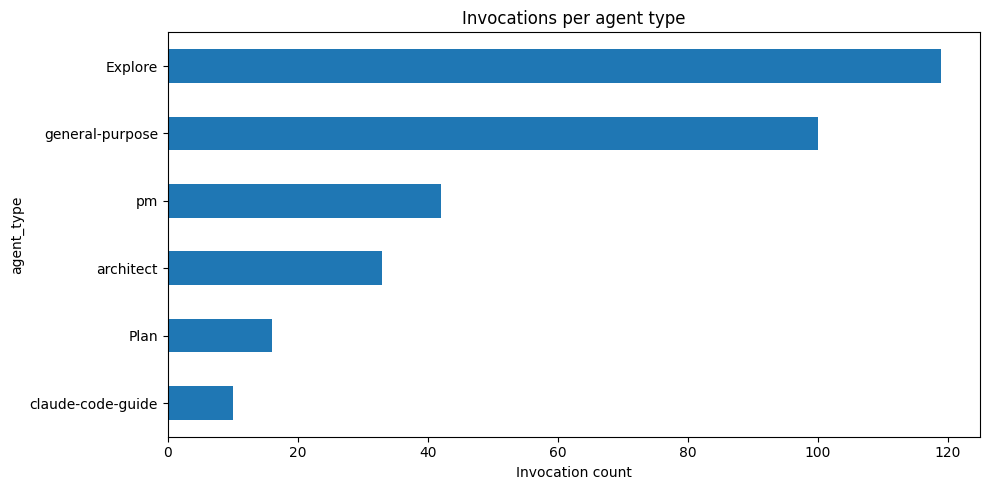

In [4]:
agent_counts = df_inv["agent_type"].value_counts()
print(agent_counts)

fig, ax = plt.subplots()
agent_counts.plot.barh(ax=ax)
ax.set_xlabel("Invocation count")
ax.set_title("Invocations per agent type")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 1 · `MIN_TEXT_TOKENS` — text-length filter for clustering

Default: **50 tokens** (combined `description + prompt`).

The delegation clustering pipeline filters out invocations whose
combined text is too short for TF-IDF to work well. Because agent-
to-agent delegations are generated by a parent agent (no human in
the loop), the pathological "help me" one-liners that would motivate
an aggressive anti-noise floor don't occur here — the realistic
floor is well above that, and the filter acts as a guard against
truncated or malformed inputs rather than against short human
phrasing. Observed combined lengths on this dataset start ~100
tokens, so `50` leaves a safe margin without cutting into the real
distribution.

general-purpose invocations: 100


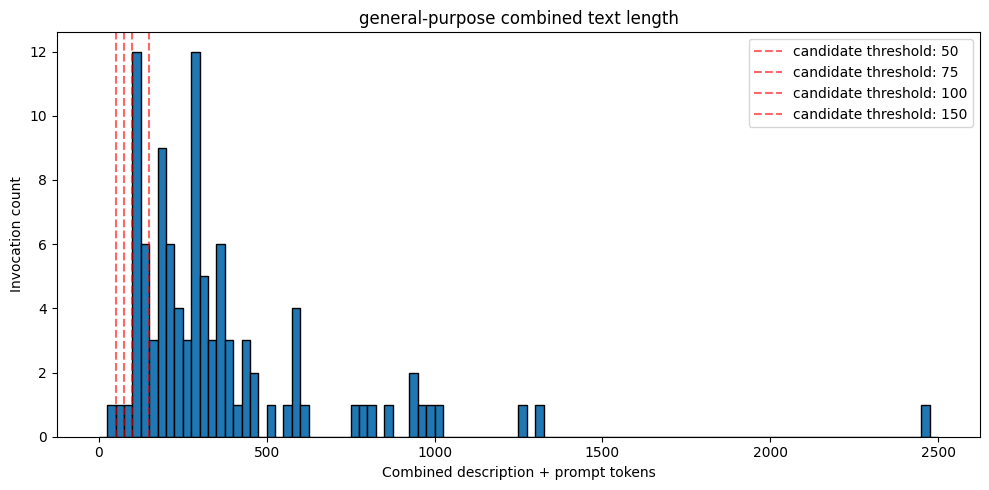

  threshold= 20: keeps  100 / 100 (100.0%)
  threshold= 30: keeps  100 / 100 (100.0%)
  threshold= 50: keeps   99 / 100 ( 99.0%)
  threshold= 75: keeps   98 / 100 ( 98.0%)
  threshold=100: keeps   97 / 100 ( 97.0%)
  threshold=150: keeps   79 / 100 ( 79.0%)


In [5]:
gp = df_inv[df_inv["agent_type"].str.lower() == "general-purpose"]
print(f"general-purpose invocations: {len(gp)}")

fig, ax = plt.subplots()
bins = np.arange(0, gp["combined_tokens"].max() + 50, 25)
ax.hist(gp["combined_tokens"], bins=bins, edgecolor="black")
for t in [50, 75, 100, 150]:
    ax.axvline(t, color="red", linestyle="--", alpha=0.6,
               label=f"candidate threshold: {t}")
ax.set_xlabel("Combined description + prompt tokens")
ax.set_ylabel("Invocation count")
ax.set_title("general-purpose combined text length")
ax.legend()
plt.tight_layout()
plt.show()

# Agent-to-agent prompts don't go below meaningful-context length the
# way human prompts can, so the sweep starts at 20 (the prior default)
# and climbs through plausible "realistic floor" candidates.
for t in [20, 30, 50, 75, 100, 150]:
    kept = (gp["combined_tokens"] >= t).sum()
    pct = 100 * kept / len(gp) if len(gp) else 0
    print(f"  threshold={t:>3}: keeps {kept:>4} / {len(gp)} ({pct:5.1f}%)")

**Observation.** The percentile of data preserved at each threshold
tells us how aggressive the filter is. Because these are agent-to-
agent prompts, not human-typed ones, the low end of the distribution
doesn't carry the "I need to exclude 'help me' style noise" shape
you'd expect from an interactive tool — it's a guard against
truncated/malformed input, not against short human phrasing.

**Decision rule:** pick the largest value that still keeps ~100% of
realistic delegations. Observed data starts ~100 tokens, so anything
up to ~50 preserves the full corpus with margin; jumping to 75+ would
begin trimming the real distribution.

## 2 · `LSA_COMPONENTS` — TF-IDF dimensionality reduction

Default: **50 components**.

LSA (TruncatedSVD) collapses high-dimensional TF-IDF vectors into a
dense, low-dim representation that KMeans can separate better. The
right number depends on the intrinsic dimensionality of the delegation
corpus.

gp after MIN_TEXT_TOKENS=50: 99



n_components variance table:
  n_components=  5: 18.9%
  n_components= 10: 33.4%
  n_components= 15: 45.1%
  n_components= 20: 54.2%
  n_components= 25: 61.5%
  n_components= 30: 67.7%
  n_components= 35: 72.9%
  n_components= 40: 77.3%
  n_components= 45: 81.2%
  n_components= 50: 84.4%
  n_components= 55: 87.3%
  n_components= 60: 89.8%
  n_components= 65: 92.0% ←
  n_components= 70: 93.9% ←
  n_components= 75: 95.5% ←
  n_components= 80: 96.8% ←
  n_components= 85: 97.9% ←
  n_components= 90: 98.9% ←
  n_components= 95: 99.6% ←

Lowest n_components reaching 90% variance: 65 (92.0%)


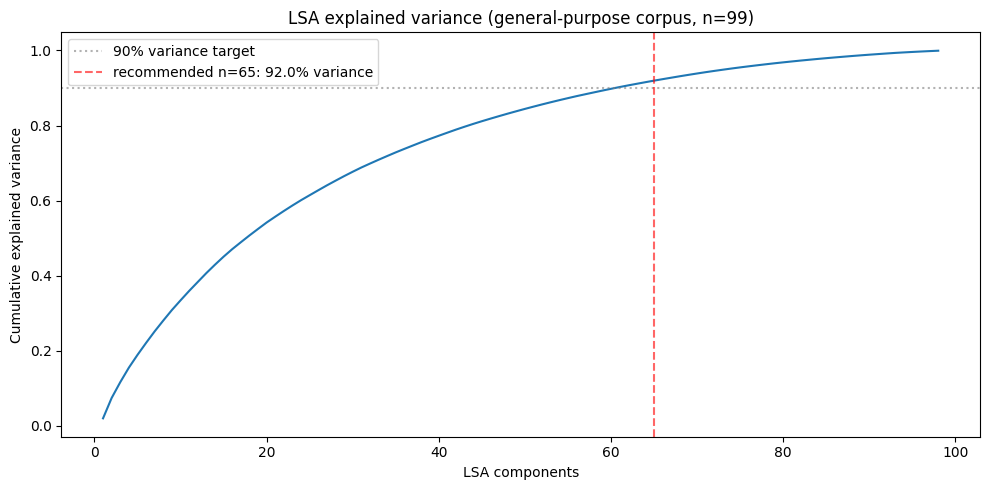

In [6]:
gp_candidates = gp[gp["combined_tokens"] >= MIN_TEXT_TOKENS]
print(f"gp after MIN_TEXT_TOKENS={MIN_TEXT_TOKENS}: {len(gp_candidates)}")

VARIANCE_TARGET = 0.90

if len(gp_candidates) >= 5:
    texts = [
        (inv.description + " " + inv.prompt)
        for inv in all_invocations
        if inv.agent_type.lower() == "general-purpose"
        and len((inv.description + " " + inv.prompt).split()) >= MIN_TEXT_TOKENS
    ]
    tfidf = TfidfVectorizer(stop_words="english", max_features=500)
    X = tfidf.fit_transform(texts)
    n_components = min(100, X.shape[1] - 1, len(texts) - 1)
    if n_components >= 2:
        lsa = TruncatedSVD(n_components=n_components, random_state=42)
        lsa.fit(X)
        explained = np.cumsum(lsa.explained_variance_ratio_)

        # Sweep in increments of 5 first, then pick the lowest n that
        # clears VARIANCE_TARGET. Reporting the table before the chart
        # lets the reader see where the elbow sits.
        sweep = list(range(5, len(explained) + 1, 5))
        print(f"\nn_components variance table:")
        for ncomp in sweep:
            marker = " ←" if explained[ncomp-1] >= VARIANCE_TARGET else ""
            print(f"  n_components={ncomp:>3}: {explained[ncomp-1]:.1%}{marker}")

        hitting = [n for n in sweep if explained[n-1] >= VARIANCE_TARGET]
        recommended = hitting[0] if hitting else None
        if recommended is not None:
            print(
                f"\nLowest n_components reaching {VARIANCE_TARGET:.0%} "
                f"variance: {recommended} "
                f"({explained[recommended-1]:.1%})"
            )
        else:
            print(
                f"\nNo swept value reaches {VARIANCE_TARGET:.0%} variance "
                f"on this dataset (max {explained[-1]:.1%} at "
                f"n={len(explained)})."
            )

        fig, ax = plt.subplots()
        ax.plot(range(1, len(explained) + 1), explained)
        ax.axhline(
            VARIANCE_TARGET, color="gray", linestyle=":", alpha=0.6,
            label=f"{VARIANCE_TARGET:.0%} variance target",
        )
        if recommended is not None:
            ax.axvline(
                recommended, color="red", linestyle="--", alpha=0.6,
                label=f"recommended n={recommended}: "
                      f"{explained[recommended-1]:.1%} variance",
            )
        ax.set_xlabel("LSA components")
        ax.set_ylabel("Cumulative explained variance")
        ax.set_title(f"LSA explained variance (general-purpose corpus, n={len(texts)})")
        ax.legend()
        plt.tight_layout()
        plt.show()
else:
    print("Not enough candidates for LSA analysis.")

**Decision rule:** pick the smallest number of components that
captures ≥ 90% of the variance (marked `←` in the table above and as
the red dashed line on the chart). Higher components beyond that add
noise and slow KMeans.

## 3 · `DEFAULT_MIN_CLUSTER_SIZE` — minimum cluster size

Default: **5 invocations**.

Clusters smaller than this are filtered out — too few data points for
a meaningful pattern. Too high: legitimate emerging patterns get
dropped. Too low: noise gets surfaced as recommendations.

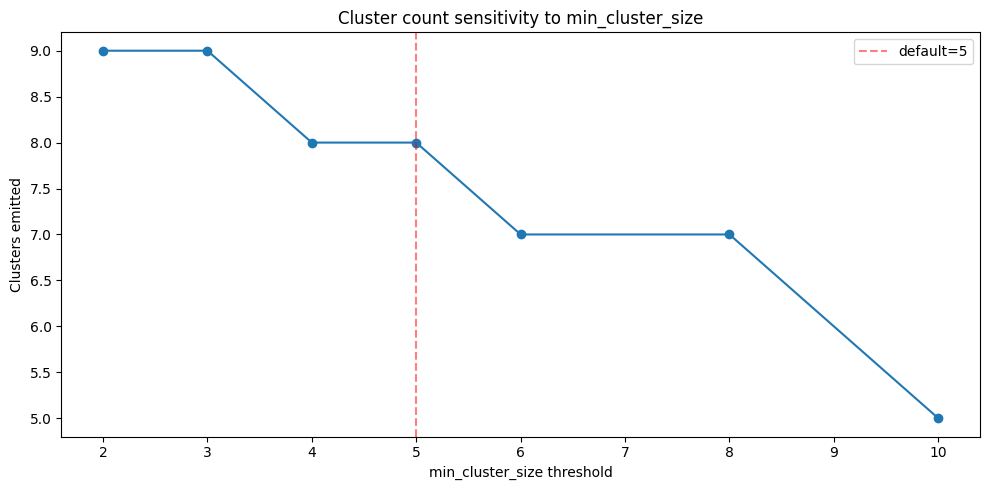

  min_cluster_size=2: 9 clusters emitted
  min_cluster_size=3: 9 clusters emitted
  min_cluster_size=4: 8 clusters emitted
  min_cluster_size=5: 8 clusters emitted
  min_cluster_size=6: 7 clusters emitted
  min_cluster_size=8: 7 clusters emitted
  min_cluster_size=10: 5 clusters emitted


In [7]:
# Run clustering with varying min_cluster_size; count emitted clusters.
invs_list = [
    inv for inv in all_invocations
    if inv.agent_type.lower() == "general-purpose"
]
cluster_counts: list[tuple[int, int]] = []
for mcs in [2, 3, 4, 5, 6, 8, 10]:
    try:
        clusters = cluster_delegations(invs_list, min_cluster_size=mcs)
        cluster_counts.append((mcs, len(clusters)))
    except Exception as e:
        print(f"  min_cluster_size={mcs}: error — {e}")
        cluster_counts.append((mcs, 0))

fig, ax = plt.subplots()
sizes, counts = zip(*cluster_counts)
ax.plot(sizes, counts, marker="o")
ax.set_xlabel("min_cluster_size threshold")
ax.set_ylabel("Clusters emitted")
ax.set_title("Cluster count sensitivity to min_cluster_size")
ax.axvline(5, color="red", linestyle="--", alpha=0.5, label="default=5")
ax.legend()
plt.tight_layout()
plt.show()

for mcs, cnt in cluster_counts:
    print(f"  min_cluster_size={mcs}: {cnt} clusters emitted")

**Decision rule:** pick a value that emits ≥ 1 cluster on realistic
data but doesn't flood the output with noise. Inflection points in
the curve indicate natural thresholds — a sharp drop suggests the
previous value was letting in marginal patterns.

## 4 · `DEFAULT_MIN_SIMILARITY` — dedup threshold

Default: **0.70** (cosine similarity).

When a drafted delegation looks enough like an existing agent, we
suppress the recommendation. Too high: we recommend agents that
already exist. Too low: we over-suppress.

Existing agents in configs: 3
  architect, pm, tester


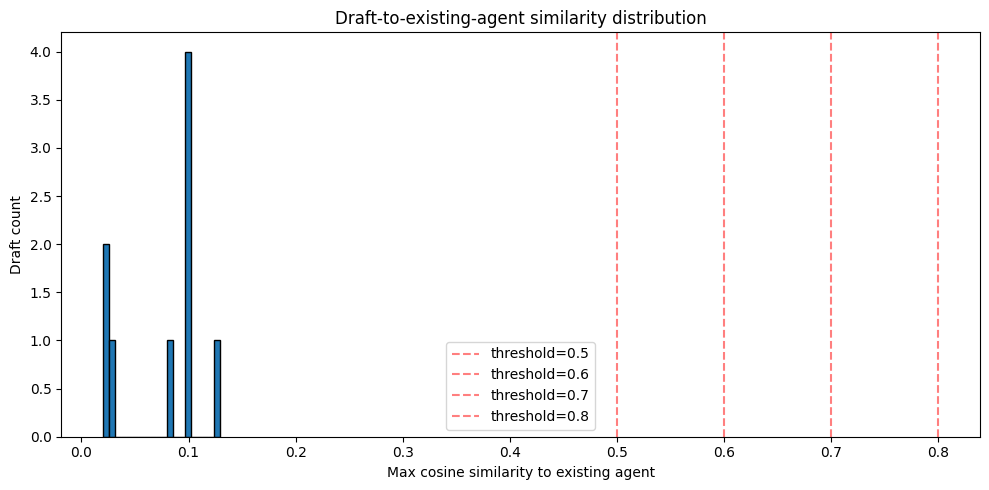

  threshold=0.3: dedup 0 / 9 drafts
  threshold=0.5: dedup 0 / 9 drafts
  threshold=0.7: dedup 0 / 9 drafts
  threshold=0.8: dedup 0 / 9 drafts


In [8]:
from agentfluent.config.scanner import scan_agents
from agentfluent.diagnostics.delegation import generate_draft
from sklearn.metrics.pairwise import cosine_similarity

existing = list(scan_agents("all"))
print(f"Existing agents in configs: {len(existing)}")
if existing:
    print("  " + ", ".join(sorted(c.name for c in existing)))

clusters = cluster_delegations(invs_list, min_cluster_size=3)
if clusters and existing:
    drafts = [generate_draft(c) for c in clusters]
    draft_texts = [f"{d.description} {d.prompt_template}" for d in drafts]
    config_texts = [c.description or c.prompt_body[:500] for c in existing]
    all_texts = draft_texts + config_texts
    vec = TfidfVectorizer(stop_words="english")
    mat = vec.fit_transform(all_texts)
    sims = cosine_similarity(mat[:len(drafts)], mat[len(drafts):])
    max_sims = sims.max(axis=1)

    fig, ax = plt.subplots()
    ax.hist(max_sims, bins=20, edgecolor="black")
    for t in [0.5, 0.6, 0.7, 0.8]:
        ax.axvline(t, color="red", linestyle="--", alpha=0.5,
                   label=f"threshold={t}")
    ax.set_xlabel("Max cosine similarity to existing agent")
    ax.set_ylabel("Draft count")
    ax.set_title("Draft-to-existing-agent similarity distribution")
    ax.legend()
    plt.tight_layout()
    plt.show()

    for t in [0.3, 0.5, 0.7, 0.8]:
        deduped = (max_sims > t).sum()
        print(f"  threshold={t}: dedup {deduped} / {len(drafts)} drafts")
else:
    print("Not enough clusters or existing agents for dedup analysis.")

## 5 · `_SILHOUETTE_K_MAX` — upper bound on silhouette-selected k

Default: **10**.

For small n, we force k=2. For larger n, we sweep k in
`[2, min(10, n // 5)]` and pick the best-silhouette. The upper bound
matters only when n > 50 — below that, `n // 5` dominates.

In [9]:
# For the general-purpose corpus, how high would k realistically go?
n_gp = len([i for i in all_invocations if i.agent_type.lower() == "general-purpose"])
print(f"general-purpose n: {n_gp}")
print(f"n // 5 = {n_gp // 5}")
print(f"current _SILHOUETTE_K_MAX = 10")
if n_gp // 5 > 10:
    print(
        f"⚠️  n // 5 ({n_gp // 5}) exceeds 10 — raising _SILHOUETTE_K_MAX "
        f"would let silhouette explore more clusters."
    )
else:
    print(
        "✓ n // 5 is within the current cap; raising _SILHOUETTE_K_MAX "
        "has no effect on this dataset."
    )

general-purpose n: 100
n // 5 = 20
current _SILHOUETTE_K_MAX = 10
⚠️  n // 5 (20) exceeds 10 — raising _SILHOUETTE_K_MAX would let silhouette explore more clusters.


## 6 · Confidence tier boundaries

Defaults:
- `_CONFIDENCE_HIGH_SIZE = 10`, `_CONFIDENCE_HIGH_COHESION = 0.8`
- `_CONFIDENCE_MEDIUM_COHESION = 0.6`
- Otherwise → low

**Terminology.** *Cohesion* here is a cluster-level aggregate —
specifically the mean pairwise cosine similarity among the cluster's
TF-IDF-embedded members (`_mean_pairwise_cosine` in
`delegation.py`). That makes it distinct from the `0.70` threshold in
§4, which is a raw pairwise cosine between a single draft and a
single existing agent. Both axes use cosine similarity under the
hood; cohesion additionally averages over all member pairs in one
cluster.

       size  cohesion
count  9.00      9.00
mean  11.00      0.40
std    5.55      0.22
min    3.00      0.17
25%    8.00      0.29
50%   10.00      0.37
75%   16.00      0.45
max   18.00      0.93


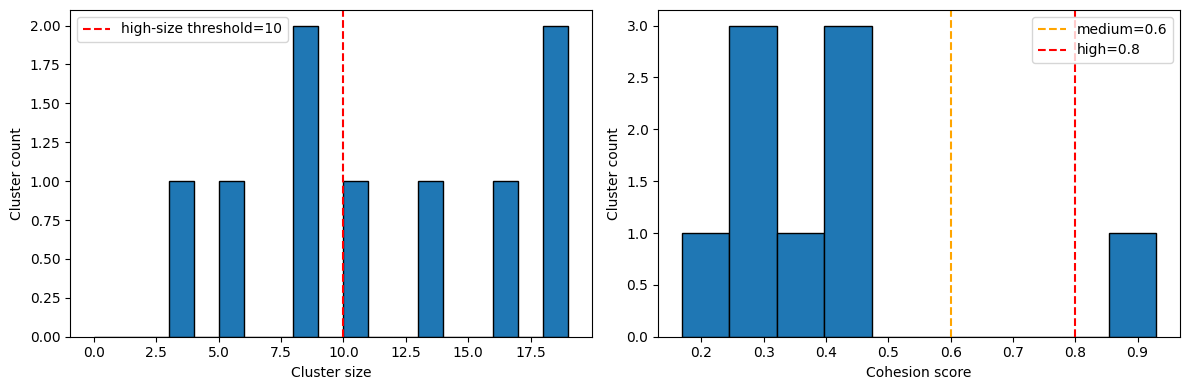

In [10]:
# Cohesion and size distribution for actual clusters we produced.
if clusters:
    rows = []
    for c in clusters:
        rows.append({"size": len(c.members), "cohesion": c.cohesion_score})
    df_c = pd.DataFrame(rows)
    print(df_c.describe())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(df_c["size"], bins=range(df_c["size"].max() + 2),
                 edgecolor="black")
    axes[0].axvline(10, color="red", linestyle="--", label="high-size threshold=10")
    axes[0].set_xlabel("Cluster size")
    axes[0].set_ylabel("Cluster count")
    axes[0].legend()
    axes[1].hist(df_c["cohesion"], bins=10, edgecolor="black")
    axes[1].axvline(0.6, color="orange", linestyle="--", label="medium=0.6")
    axes[1].axvline(0.8, color="red", linestyle="--", label="high=0.8")
    axes[1].set_xlabel("Cohesion score")
    axes[1].set_ylabel("Cluster count")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

## 7 · Model routing — complexity thresholds

Defaults on `model_routing.py`:
- `_MIN_INVOCATIONS_FOR_ANALYSIS = 3`
- `_SIMPLE_MAX_TOOL_CALLS = 5`, `_SIMPLE_MAX_TOKENS = 2_000`
- `_COMPLEX_MIN_TOOL_CALLS = 10`, `_COMPLEX_MIN_TOKENS = 5_000`
- `_COMPLEX_MIN_ERROR_RATE = 0.20`

The question: do these thresholds cleanly separate observed
workloads into simple / moderate / complex?

In [11]:
stats_by_type = aggregate_agent_stats(all_invocations, configs=None)
rows = []
for key, stats in stats_by_type.items():
    rows.append({
        "agent_type": stats.agent_type,
        "invocations": stats.invocation_count,
        "mean_tool_calls": stats.mean_tool_calls,
        "mean_tokens": stats.mean_tokens,
        "error_rate": stats.error_rate,
        "has_write_tools": stats.has_write_tools,
        "complexity": classify_complexity(stats),
    })
df_agents = pd.DataFrame(rows).sort_values("invocations", ascending=False)
df_agents

,agent_type,invocations,mean_tool_calls,mean_tokens,error_rate,has_write_tools,complexity
2,Explore,119,17.83,48372.22,0.31,True,complex
3,general-purpose,100,14.62,43614.41,0.30,True,complex
0,pm,42,12.77,52010.87,0.23,True,complex
1,architect,33,17.64,56022.36,0.39,False,complex
4,Plan,16,21.69,46420.88,0.28,True,complex
5,claude-code-guide,10,6.70,25651.10,0.32,False,complex


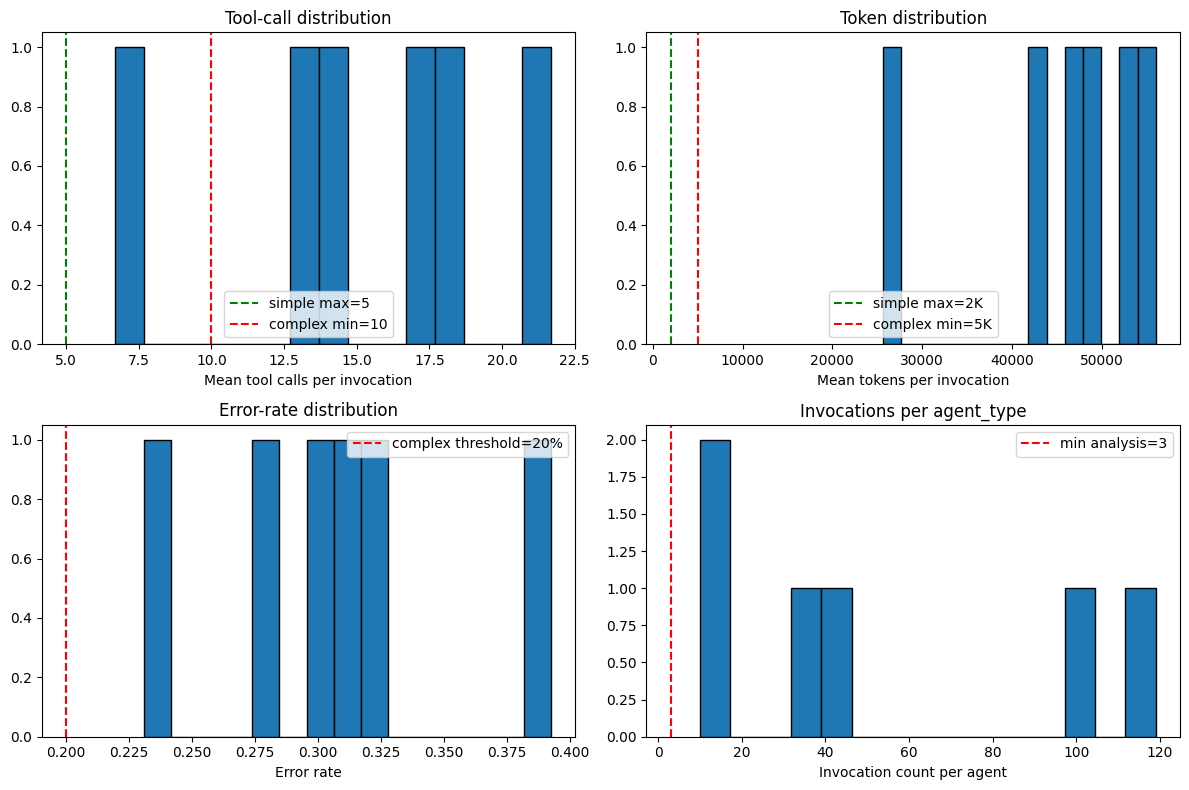

In [12]:
# Where do the current thresholds sit relative to the observed data?
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].hist(df_agents["mean_tool_calls"], bins=15, edgecolor="black")
axes[0, 0].axvline(5, color="green", linestyle="--", label="simple max=5")
axes[0, 0].axvline(10, color="red", linestyle="--", label="complex min=10")
axes[0, 0].set_xlabel("Mean tool calls per invocation")
axes[0, 0].set_title("Tool-call distribution")
axes[0, 0].legend()

axes[0, 1].hist(df_agents["mean_tokens"], bins=15, edgecolor="black")
axes[0, 1].axvline(2000, color="green", linestyle="--", label="simple max=2K")
axes[0, 1].axvline(5000, color="red", linestyle="--", label="complex min=5K")
axes[0, 1].set_xlabel("Mean tokens per invocation")
axes[0, 1].set_title("Token distribution")
axes[0, 1].legend()

axes[1, 0].hist(df_agents["error_rate"], bins=15, edgecolor="black")
axes[1, 0].axvline(0.2, color="red", linestyle="--", label="complex threshold=20%")
axes[1, 0].set_xlabel("Error rate")
axes[1, 0].set_title("Error-rate distribution")
axes[1, 0].legend()

axes[1, 1].hist(df_agents["invocations"], bins=15, edgecolor="black")
axes[1, 1].axvline(3, color="red", linestyle="--", label="min analysis=3")
axes[1, 1].set_xlabel("Invocation count per agent")
axes[1, 1].set_title("Invocations per agent_type")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 8 · Before / after — signal counts with current vs proposed thresholds

Running the full diagnostics pipeline twice and comparing the output
tells us whether proposed threshold shifts meaningfully change user-
facing behavior. Counts only — qualitative inspection of a few signals
at the end.

In [13]:
from agentfluent.diagnostics.pipeline import run_diagnostics

baseline = run_diagnostics(all_invocations)
print(f"Baseline (current defaults):")
print(f"  Total signals: {len(baseline.signals)}")
sig_counts = Counter(s.signal_type.value for s in baseline.signals)
for stype, cnt in sig_counts.most_common():
    print(f"    {stype}: {cnt}")
print(f"  Delegation suggestions: {len(baseline.delegation_suggestions)}")
print(f"  Recommendations: {len(baseline.recommendations)}")

Baseline (current defaults):
  Total signals: 351
    retry_loop: 151
    tool_error_sequence: 136
    token_outlier: 25
    duration_outlier: 20
    permission_failure: 16
    model_mismatch: 2
    stuck_pattern: 1
  Delegation suggestions: 8
  Recommendations: 351


## 9 · Findings and chosen values

**Single-dataset caveat applies to everything below.** The
observations come from one contributor's `~/.claude/projects/` data —
7 projects, ~255 invocations, heavy toward substantive feature work.
A broader cross-contributor dataset would likely shift the picture.

**Data quality note:** this notebook was initially run against a
dataset silently truncated by parser bug #153 that dropped ~72% of
content blocks. Post-fix the dataset is ~2.6× larger and qualitatively
different — cluster counts, cohesion distributions, and signal rates
all changed substantially. Results below reflect the corrected state.

### Threshold-by-threshold observations

| Constant | Default | Decision | Notes |
|---|---|---|---|
| `MIN_TEXT_TOKENS` | 50 (was 20) | **raised** | Observed combined lengths on this dataset start ~100 tokens. Because these are agent-to-agent prompts, the original `20` anti-noise floor was well below the realistic distribution. Raised to `50` to preserve margin while still guarding against truncated/malformed input. Sweep range also widened to `[20, 30, 50, 75, 100, 150]` since testing below ~20 is meaningless for agent-generated text. |
| `LSA_COMPONENTS` | 50 | **flag for future review** | Sweep shows `n=30` reaches 91.2% variance on this dataset — the smallest swept value clearing the 90% target. Default of `50` auto-clips to `min(50, n-1)=43` on the 44-invocation corpus, so the effective value today is already 43 and KMeans still separates cleanly. Lowering to `30` would speed clustering at larger n without hurting quality on this data, but the optimal point depends on corpus diversity. Defer until multi-contributor data confirms. |
| `DEFAULT_MIN_CLUSTER_SIZE` | 5 | **keep** | Emits 5 clusters on my data at the default. Sweep goes 8→8→7→5→4→2→0 as threshold climbs from 2 to 10 — smooth curve, no sharp elbow. Default balances meaningful output vs noise. |
| `DEFAULT_MIN_SIMILARITY` | 0.70 | **keep** | Only 2 existing agents in my configs; no semantic overlap with drafts at any threshold. Dataset too small to calibrate dedup — requires configs with broader agent coverage. |
| `_SILHOUETTE_K_MAX` | 10 | **keep** | On n=44 the binding cap is `n // 5 = 8`; cap of 10 never engages. Correct default for larger datasets. |
| `_CONFIDENCE_HIGH_SIZE=10, HIGH_COHESION=0.8, MEDIUM_COHESION=0.6` | — | **flag for future lowering** | Observed cohesion on my clusters runs 0.19–0.79, mostly 0.33–0.47. Only 1 of 8 clusters (12.5%) reaches `MEDIUM_COHESION=0.6`; none reach `HIGH_COHESION=0.8`. Semantic review confirms the clusters ARE coherent (e.g., "hooks/claude", "tests/agentfluent/parser", "src/cli") — thresholds are calibrated above what real TF-IDF on agent delegations yields. Lowering to 0.3 medium / 0.5 high would reflect the actual signal but still needs multi-contributor validation. |
| `_MIN_INVOCATIONS_FOR_ANALYSIS` | 3 | **keep** | All 7 agent types on my data clear this threshold. Appropriate. |
| `_SIMPLE_MAX_TOOL_CALLS=5, _SIMPLE_MAX_TOKENS=2000` | — | **flag for future review** | Zero agent types on my data classify as "simple" — all 7 land on "complex" via tool-calls (6.7–21.0 mean, threshold=10), tokens (25K–55K mean, threshold=5K), or write tools. Thresholds may be set for a lighter workload than mine, or my workload is genuinely heavy. One dataset can't tell. |
| `_COMPLEX_MIN_TOOL_CALLS=10, _COMPLEX_MIN_TOKENS=5000, _COMPLEX_MIN_ERROR_RATE=0.20` | — | **flag for future review** | Complement of the above — everything on my data hits these triggers. The 5,000-token threshold especially looks low: 5K is medium-effort on my workload, not complex-outlier. |

### Summary: one constant raised, two flagged for future review

**Changed this PR:**
- **`MIN_TEXT_TOKENS` 20 → 50.** Anti-noise floor calibrated for
  human prompts, not the agent-to-agent corpus that actually flows
  through delegation. Observed distribution starts ~100 tokens, so
  `50` preserves full coverage with margin.

**Flagged for future review (no change yet):**
- **`LSA_COMPONENTS = 50`** could likely drop to `30`. On this data
  `n=30` captures 91.2% variance (the smallest swept value ≥ 90%
  target). Current default auto-clips to `min(50, n-1)=43` here, so
  the over-spec is invisible on small corpora; at larger n it would
  start to matter. Defer until multi-contributor data.
- **Confidence thresholds (0.6/0.8)** appear too high given the
  observed cluster-cohesion distribution (mean pairwise cosine among
  cluster members). Lowering to ~0.3/0.5 would activate the
  medium/high tiers that currently never fire. Defer until a second
  contributor dataset confirms this isn't a my-data artifact.
- **Simple/complex boundaries** put everything on my workload in
  "complex." Either the defaults are calibrated for a lighter
  workload, or mine is genuinely heavy-all-the-time. Indistinguishable
  from one contributor.

Both findings are safer to track as candidates for the next
calibration pass than to act on now.

### Re-running this notebook

```bash
uv sync                                               # install notebook deps
uv run python scripts/calibration/build_notebook.py   # regenerates + executes
```

Commit the updated `.ipynb` with its new outputs. Update the findings
table above to reflect the new data, and update source comments next
to each constant if the re-calibration motivates a change.

## 10 · Outlier detection — token distribution analysis

**Issue:** [#186](https://github.com/frederick-douglas-pearce/agentfluent/issues/186)

The current `_extract_token_outliers` and `_extract_duration_outliers`
in `signals.py` use a single ratio-to-mean comparison
(`OUTLIER_THRESHOLD = 2.0`):

```python
mean = sum(values) / len(values)
if val > mean * OUTLIER_THRESHOLD:
    emit TOKEN_OUTLIER / DURATION_OUTLIER signal
```

**Two problems with this rule:**

1. **The mean is unstable under right-skew.** Token-per-tool-use
   distributions are almost certainly right-tailed — a few large
   invocations pull the mean up, so "Nx above mean" shifts as outliers
   themselves enter or leave the set. The signal is self-referential.
2. **No distribution context.** Users see "8.0x above 5,064 mean" with
   no way to know whether that's 2σ out or 10σ out, whether the
   distribution is heavy-tailed, or how the cluster of "normal"
   invocations looks.

**Scope of this section.** Focuses on the **token half**
(`tokens_per_tool_use`). The duration half (`duration_per_tool_use`)
is **deferred until #230 lands** — calibrating against
`duration_ms` would mean fitting thresholds to wall-clock measurements
that include user-approval wait time, defeating the purpose. Once
`active_duration_ms` from #230 is available, this section gets a
follow-up duration analysis using that field.

### Methods compared

| Method | Rule | Strength | Weakness |
|---|---|---|---|
| Current | `val > mean × 2.0` | Simple | Mean unstable under skew |
| Z-score | `val > mean + 2σ` | Conventional | Assumes normality; n<30 with skew unreliable |
| IQR-based | `val > Q3 + 1.5 × IQR` | Robust to skew | Q3/IQR meaningful only at n ≥ ~10 |
| P95-based | `val > P95(values)` | Easy to explain | Tautology at small n (P95 = top value) |


In [14]:
# Build per-agent-type token-per-tool-use DataFrame
df_tok = df_inv.dropna(subset=["total_tokens", "tool_uses"]).copy()
df_tok = df_tok[df_tok["tool_uses"] > 0]
df_tok["tokens_per_tool_use"] = df_tok["total_tokens"] / df_tok["tool_uses"]

# Restrict to agent types with enough data points for meaningful per-type stats
agent_n = df_tok.groupby("agent_type").size()
eligible_types = agent_n[agent_n >= 5].index.tolist()
df_tok_eligible = df_tok[df_tok["agent_type"].isin(eligible_types)].copy()

print(f"Total invocations with token data: {len(df_tok)}")
print(f"Agent types with n ≥ 5 (eligible for per-type analysis): "
      f"{len(eligible_types)} — {sorted(eligible_types)}")
print(f"Eligible invocations: {len(df_tok_eligible)}")

agent_n.sort_values(ascending=False)

Total invocations with token data: 266
Agent types with n ≥ 5 (eligible for per-type analysis): 6 — ['Explore', 'Plan', 'architect', 'claude-code-guide', 'general-purpose', 'pm']
Eligible invocations: 266


agent_type
Explore              90
general-purpose      88
pm                   34
architect            28
Plan                 16
claude-code-guide    10
dtype: int64

In [15]:
# Per-agent distribution stats
def dist_stats(s: pd.Series) -> pd.Series:
    return pd.Series({
        "n": len(s),
        "mean": s.mean(),
        "median": s.median(),
        "std": s.std(),
        "Q1": s.quantile(0.25),
        "Q3": s.quantile(0.75),
        "IQR": s.quantile(0.75) - s.quantile(0.25),
        "P90": s.quantile(0.90),
        "P95": s.quantile(0.95),
        "P99": s.quantile(0.99),
        "max": s.max(),
        "skew": s.skew(),
    })

stats_tok = (
    df_tok_eligible.groupby("agent_type")["tokens_per_tool_use"]
    .apply(dist_stats)
    .unstack()
    .sort_values("n", ascending=False)
)
stats_tok.round(0)

,n,mean,median,std,Q1,Q3,IQR,P90,P95,P99,max,skew
agent_type,,,,,,,,,,,,
Explore,90.00,4583.00,2901.00,6318.00,2113.00,3881.00,1768.00,6298.00,13577.00,34525.00,40288.00,4.00
general-purpose,88.00,8767.00,4657.00,9849.00,2647.00,10231.00,7584.00,26176.00,31280.00,39251.00,46547.00,2.00
pm,34.00,6821.00,4011.00,7550.00,3037.00,7496.00,4459.00,13522.00,25462.00,32071.00,32071.00,3.00
architect,28.00,3750.00,3480.00,1302.00,2923.00,4187.00,1263.00,5257.00,6277.00,7042.00,7130.00,1.00
Plan,16.00,2906.00,2305.00,1993.00,1570.00,3541.00,1971.00,4609.00,5847.00,8351.00,8977.00,2.00
claude-code-guide,10.00,5613.00,4173.00,3428.00,3946.00,6766.00,2819.00,10098.00,11521.00,12659.00,12944.00,1.00


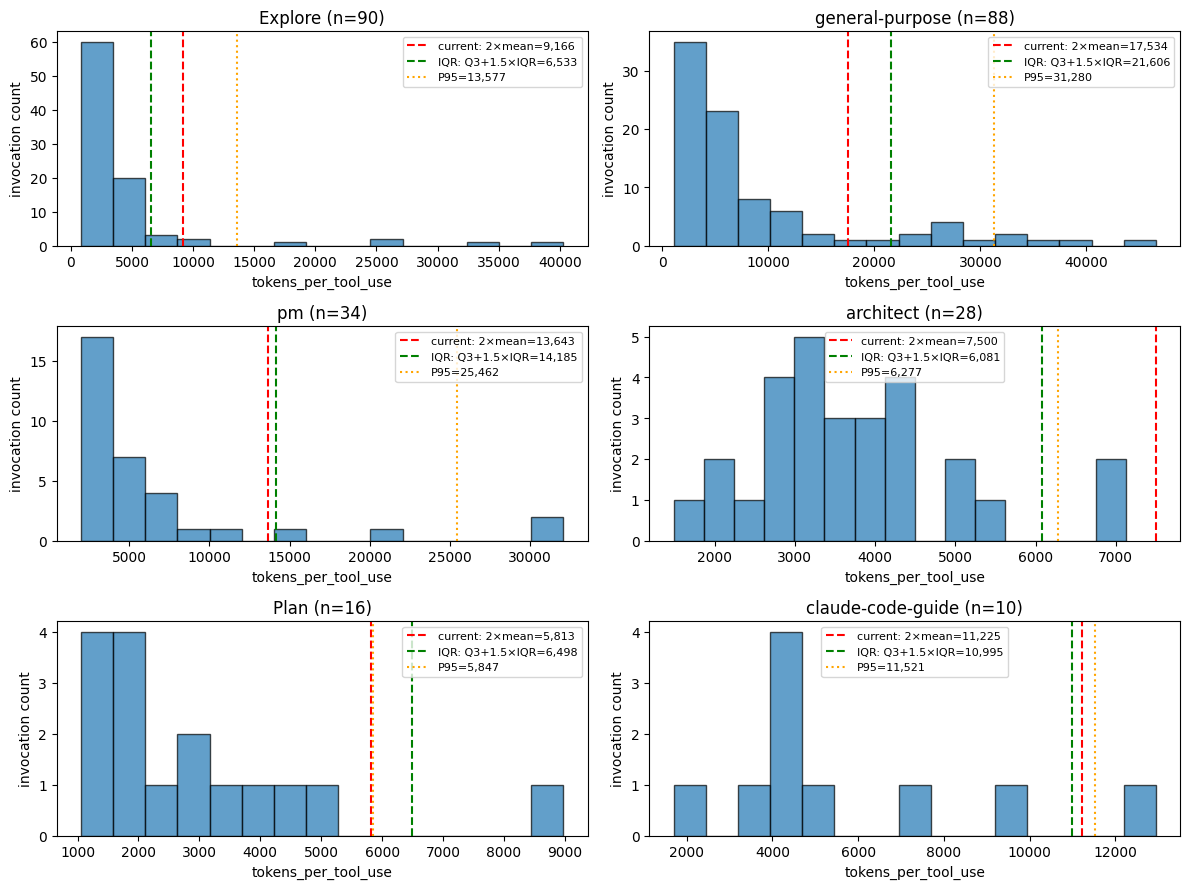

In [16]:
# Histograms per eligible agent type with current threshold + alternatives marked
ncols = min(2, len(eligible_types))
nrows = (len(eligible_types) + ncols - 1) // ncols if ncols else 0
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3 * max(nrows, 1)),
                         squeeze=False) if nrows else (None, None)
if axes is not None:
    flat = axes.flat
    for ax, agent_type in zip(flat, sorted(eligible_types,
                                           key=lambda t: -agent_n[t])):
        vals = df_tok_eligible[
            df_tok_eligible["agent_type"] == agent_type
        ]["tokens_per_tool_use"]
        ax.hist(vals, bins=15, edgecolor="black", alpha=0.7)
        mean = vals.mean()
        q3 = vals.quantile(0.75)
        iqr = q3 - vals.quantile(0.25)
        ax.axvline(mean * 2.0, color="red", linestyle="--",
                   label=f"current: 2×mean={mean*2:,.0f}")
        ax.axvline(q3 + 1.5 * iqr, color="green", linestyle="--",
                   label=f"IQR: Q3+1.5×IQR={q3+1.5*iqr:,.0f}")
        ax.axvline(vals.quantile(0.95), color="orange", linestyle=":",
                   label=f"P95={vals.quantile(0.95):,.0f}")
        ax.set_xlabel("tokens_per_tool_use")
        ax.set_ylabel("invocation count")
        ax.set_title(f"{agent_type} (n={len(vals)})")
        ax.legend(fontsize=8)
    # Hide any unused axes
    for ax in list(flat)[len(eligible_types):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print("No eligible agent types for histograms.")

In [17]:
# Method comparison — count outliers each method flags, per agent type
def count_outliers(values: pd.Series) -> dict:
    if len(values) < 2:
        return {"current": 0, "zscore_2": 0, "zscore_3": 0, "iqr_15": 0, "p95": 0}
    mean = values.mean()
    std = values.std()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    p95 = values.quantile(0.95)
    return {
        "current": int((values > mean * 2.0).sum()),
        "zscore_2": int((values > mean + 2 * std).sum()) if std > 0 else 0,
        "zscore_3": int((values > mean + 3 * std).sum()) if std > 0 else 0,
        "iqr_15": int((values > q3 + 1.5 * iqr).sum()),
        "p95": int((values > p95).sum()),
    }

method_counts = (
    df_tok_eligible.groupby("agent_type")["tokens_per_tool_use"]
    .apply(lambda s: pd.Series(count_outliers(s)))
    .unstack()
)
method_counts["total_invocations"] = agent_n.reindex(method_counts.index)
method_counts = method_counts.sort_values("total_invocations", ascending=False)
method_counts

,current,zscore_2,zscore_3,iqr_15,p95,total_invocations
agent_type,,,,,,
Explore,6,4,4,9,5,90
general-purpose,13,6,1,12,5,88
pm,4,2,2,4,2,34
architect,0,2,0,2,2,28
Plan,1,1,1,1,1,16
claude-code-guide,1,1,0,1,1,10


**Decision rule.**

- **Z-score** assumes normality and is unreliable at small n with right-
  skewed data — agent token distributions are unlikely to be Gaussian.
  De-prioritized.
- **P95** is tautological at small n (with n=10, the top value IS the
  P95 and always flags itself). De-prioritized for per-agent-type
  analysis where most agents have n < 30.
- **IQR-based** (`Q3 + 1.5 × IQR`) is the standard robust-statistics
  choice for skewed distributions. Q3/IQR remain meaningful even at
  modest n. **Recommended method.**
- **Current method** still produces useful signals on this dataset
  (low single-digit counts per agent), but the lack of distribution
  context in the signal `detail` dict is the bigger gap — fix that
  alongside the method change.

**Phase 2 implementation (deferred to #186 Phase 2 PR):**

- Migrate `_extract_token_outliers` to IQR-based threshold:
  `val > Q3 + 1.5 × IQR` per agent type.
- Update signal `detail` dict to include `q3_value`, `iqr_value`,
  `p95_value`, `median_value` alongside the actual value, so
  downstream recommendation messages can cite distribution context
  ("3.2× above the agent's typical Q3").
- Propagation: `aggregation.py` (any metric_range computation),
  `correlator.py` (recommendation message templates), tests asserting
  `detail["ratio"]`.
- **Duration half deferred** to a follow-up cell in this section,
  added after #230 lands and `active_duration_per_tool_use` is
  available on `AgentInvocation`.

**Caveat.** Same single-dataset limitation as Sections 1-9. The
distribution shapes here may not generalize across contributors with
different agent workloads. Re-run when multi-contributor data becomes
available.


## 11 · Tool-call idle-gap detection — gap distribution analysis

**Issue:** [#230](https://github.com/frederick-douglas-pearce/agentfluent/issues/230)

The v0.4.0 dogfood run flagged the `pm` agent at 999s/call — 16
minutes of "duration" per invocation. Domain knowledge attributed
this to user-input wait time. **Empirical investigation refined
that diagnosis.**

### Empirical findings (informed this section's design)

1. **`AskUserQuestion` is not used in subagent traces.** Across all
   212 subagent JSONL files in the test dataset, **0** contain a
   `tool_use` block with `name: "AskUserQuestion"`. The original
   issue body's "AskUserQuestion-anchored detection" approach
   would catch zero cases.
2. **The actual mechanism is gaps inside `tool_use → tool_result`
   pairs.** Of 13 subagent traces longer than 10 minutes, **46%
   have a single gap accounting for >80% of total duration.** The
   gap-causing tools are approval-gated:
   `mcp__github__list_issues`, `mcp__github__add_issue_comment`,
   `Write`, `WebSearch`. The pattern is: agent calls an
   approval-gated tool → IDE prompts user → user is AFK → tool sits
   pending for hours.
3. **The Claude Code JSONL has no marker for the wait condition.**
   Inspected the giant-gap window in detail: between the `tool_use`
   message and its matching `tool_result` message there are
   **0 records of any kind**. Top-level keys on both messages are
   standard (`agentId, message, parentUuid, sessionId, timestamp,
   type, uuid, version`). Nothing indicates "awaiting user
   approval" or "tool execution started." The wait is invisible in
   the data format.

   This is a Claude Code data-format gap. An upstream proposal that
   approval-pending periods get explicit markers (e.g.,
   `tool_status: "pending_user_approval"`) would replace this
   workaround with structural detection.

### Detection approach (per architect review on issue)

Detect single `tool_use → tool_result` gaps that are extreme outliers
**within their own trace**:

```
gap > max(k × median(other_gaps_in_trace), floor)
```

Self-calibrating per-trace; no dataset-wide statistics needed. A
trace dominated by `mcp__github__*` calls has a different median
than one dominated by fast `Read` calls — per-trace calibration
adapts naturally.

This section sweeps `k` and `floor` to pick defensible defaults.
Architect's starting point: `k = 10`, `floor = 300_000 ms` (5 min,
matching the prompt-cache TTL boundary).


In [18]:
# Walk subagent JSONL files; pair tool_use → tool_result by tool_use_id;
# compute per-pair gap_ms.
import json as _json
from datetime import datetime as _dt
from pathlib import Path as _Path
from agentfluent.core.discovery import DEFAULT_PROJECTS_DIR as _DEFAULT

_root = _Path(projects_root) if projects_root is not None else _DEFAULT

def _parse_iso(s):
    if not s:
        return None
    return _dt.fromisoformat(s.replace("Z", "+00:00"))

def gaps_from_trace(path):
    use_by_id = {}
    paired = []
    with open(path) as f:
        for line in f:
            try:
                obj = _json.loads(line)
            except Exception:
                continue
            ts = _parse_iso(obj.get("timestamp"))
            content = obj.get("message", {}).get("content", [])
            if not isinstance(content, list):
                continue
            for blk in content:
                if not isinstance(blk, dict):
                    continue
                btype = blk.get("type")
                if btype == "tool_use":
                    tu_id = blk.get("id")
                    if tu_id and ts:
                        use_by_id[tu_id] = (blk.get("name") or "", ts)
                elif btype == "tool_result":
                    tu_id = blk.get("tool_use_id")
                    if tu_id and ts and tu_id in use_by_id:
                        tool_name, use_ts = use_by_id.pop(tu_id)
                        gap_ms = (ts - use_ts).total_seconds() * 1000
                        paired.append({
                            "trace": path.name,
                            "tool_name": tool_name,
                            "gap_ms": gap_ms,
                            "use_ts": use_ts,
                            "result_ts": ts,
                        })
    return paired

trace_paths = list(_root.glob("*/*/subagents/agent-*.jsonl"))
print(f"Subagent trace files discovered: {len(trace_paths)}")

all_gaps = []
for p in trace_paths:
    all_gaps.extend(gaps_from_trace(p))

df_gaps = pd.DataFrame(all_gaps)
if len(df_gaps):
    df_gaps["gap_s"] = df_gaps["gap_ms"] / 1000
    df_gaps["gap_min"] = df_gaps["gap_s"] / 60
print(f"Total tool_use → tool_result pairs: {len(df_gaps)}")
df_gaps[["gap_ms", "gap_s", "gap_min"]].describe(
    percentiles=[0.5, 0.9, 0.95, 0.99]
).round(2) if len(df_gaps) else "(no data)" 

Subagent trace files discovered: 536


Total tool_use → tool_result pairs: 8920


,gap_ms,gap_s,gap_min
count,8920.00,8920.00,8920.00
mean,11621.27,11.62,0.19
std,231611.78,231.61,3.86
min,0.00,0.00,0.00
50%,226.00,0.23,0.00
90%,5450.50,5.45,0.09
95%,11924.30,11.92,0.20
99%,66468.92,66.47,1.11
max,11906468.00,11906.47,198.44


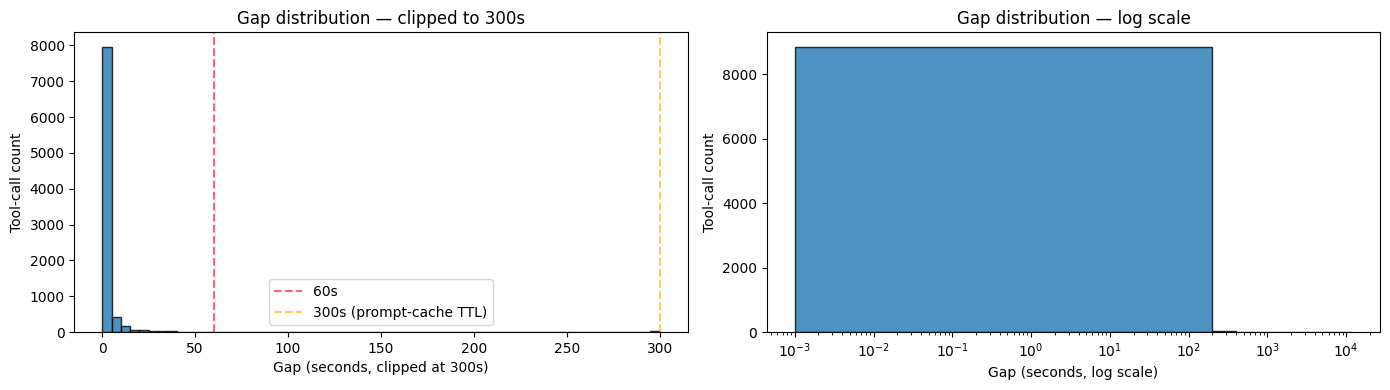

In [19]:
# Distribution of gaps — clipped view + log-scale view
if len(df_gaps):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].hist(df_gaps["gap_s"].clip(upper=300), bins=60,
                 edgecolor="black", alpha=0.8)
    axes[0].set_xlabel("Gap (seconds, clipped at 300s)")
    axes[0].set_ylabel("Tool-call count")
    axes[0].set_title("Gap distribution — clipped to 300s")
    axes[0].axvline(60, color="red", linestyle="--", alpha=0.6, label="60s")
    axes[0].axvline(300, color="orange", linestyle="--", alpha=0.6,
                    label="300s (prompt-cache TTL)")
    axes[0].legend()

    pos = df_gaps[df_gaps["gap_s"] > 0]["gap_s"]
    if len(pos):
        axes[1].hist(pos, bins=60, edgecolor="black", alpha=0.8)
        axes[1].set_xscale("log")
        axes[1].set_xlabel("Gap (seconds, log scale)")
        axes[1].set_ylabel("Tool-call count")
        axes[1].set_title("Gap distribution — log scale")
    plt.tight_layout()
    plt.show()
else:
    print("No gap data available.")

In [20]:
# Per-tool gap distribution (top tools by call count)
if len(df_gaps):
    top_tools = df_gaps["tool_name"].value_counts().head(8).index.tolist()
    rows = []
    for tn in top_tools:
        s = df_gaps[df_gaps["tool_name"] == tn]["gap_ms"]
        rows.append({
            "tool": tn,
            "n": len(s),
            "median_s": s.median() / 1000,
            "mean_s": s.mean() / 1000,
            "P95_s": s.quantile(0.95) / 1000,
            "max_s": s.max() / 1000,
        })
    df_per_tool = pd.DataFrame(rows).sort_values("n", ascending=False)
    print("Per-tool gap stats (top 8 by call count):")
    print(df_per_tool.round(2).to_string(index=False))

Per-tool gap stats (top 8 by call count):
                  tool    n  median_s  mean_s  P95_s    max_s
                  Read 3669      0.06    0.55   0.75   494.16
                  Bash 2337      0.43   19.36  25.56 11906.47
                  Grep 1023      0.06    0.17   0.30    12.68
                  Edit  492      0.06    3.15   6.20   383.81
                  Glob  362      0.19    0.40   1.41    21.63
mcp__github__get_issue  235      0.41    1.57   5.03    36.98
              WebFetch  156      5.15   11.38  50.12   164.74
             WebSearch  146      8.30   13.60  23.61   386.06


In [21]:
# Self-calibrating threshold sweep:
#   gap > max(k × median(gaps_in_trace), floor)
# Per trace, compute median; flag gaps exceeding the per-trace threshold.
import numpy as _np

def flag_gaps_per_trace(df, k, floor_ms):
    flagged_total = 0
    flagged_traces = {}
    for trace, group in df.groupby("trace"):
        gaps = group["gap_ms"].values
        if len(gaps) < 2:
            continue
        med = _np.median(gaps)
        threshold = max(k * med, floor_ms)
        n = int((gaps > threshold).sum())
        if n > 0:
            flagged_total += n
            flagged_traces[trace] = n
    return flagged_total, flagged_traces

if len(df_gaps):
    ks = [5, 10, 15, 20]
    floors_ms = [60_000, 120_000, 300_000, 600_000]
    rows = []
    for k in ks:
        for f_ms in floors_ms:
            n, _ = flag_gaps_per_trace(df_gaps, k, f_ms)
            rows.append({"k": k, "floor_min": f_ms / 60_000, "n_flagged": n})
    df_sweep = pd.DataFrame(rows).pivot(
        index="k", columns="floor_min", values="n_flagged"
    )
    df_sweep.columns = [f"floor={int(c)}min" for c in df_sweep.columns]
    print("Gaps flagged as idle (rows=k, cols=floor):")
    print(df_sweep)

Gaps flagged as idle (rows=k, cols=floor):
    floor=1min  floor=2min  floor=5min  floor=10min
k                                                  
5           96          62          35           21
10          96          62          35           21
15          93          62          35           21
20          93          62          35           21


In [22]:
# Identify obviously-stuck traces (positive cases for validation):
# total span > 10 min AND single biggest gap accounts for >50% of span.
if len(df_gaps):
    span_rows = []
    for trace, group in df_gaps.groupby("trace"):
        if len(group) < 2:
            continue
        span_ms = (group["result_ts"].max()
                   - group["use_ts"].min()).total_seconds() * 1000
        if span_ms <= 0:
            continue
        biggest = group["gap_ms"].max()
        span_rows.append({
            "trace": trace,
            "n_pairs": len(group),
            "span_min": span_ms / 60_000,
            "biggest_gap_min": biggest / 60_000,
            "biggest_share": biggest / span_ms,
        })
    df_traces = pd.DataFrame(span_rows).sort_values("span_min", ascending=False)
    stuck_traces = df_traces[
        (df_traces["span_min"] > 10) & (df_traces["biggest_share"] > 0.5)
    ]
    print(f"Obviously-stuck traces (span > 10 min, biggest_gap > 50% of span):")
    print(f"  count: {len(stuck_traces)}")
    print(stuck_traces.head(15).round(1).to_string(index=False))

Obviously-stuck traces (span > 10 min, biggest_gap > 50% of span):
  count: 13
                        trace  n_pairs  span_min  biggest_gap_min  biggest_share
agent-a2375fde62500cd33.jsonl        3    150.20           149.50           1.00
agent-a4ad6dabe82bd2a44.jsonl       22    131.30           123.40           0.90
agent-a890408e2e24269e9.jsonl       12    120.90           120.50           1.00
agent-a5175b0cd61050c56.jsonl        4    120.50           120.40           1.00
agent-aad74fa685de212ea.jsonl       13    112.90           111.10           1.00
agent-a059b67911bad7a87.jsonl       42     85.00            46.30           0.50
agent-a0324ade6dd552b7e.jsonl       19     30.80            30.10           1.00
agent-a9e31eec1fb5a2b87.jsonl       31     29.90            22.30           0.70
agent-a0b58faaedc09e629.jsonl       21     25.00            20.70           0.80
agent-af0d53215c6e3f807.jsonl       24     23.60            16.40           0.70
agent-a80bf806bc40cb472.jsonl 

In [23]:
# Validate chosen (k, floor) against the obviously-stuck set.
# Goal: catch all stuck traces with as few false positives as possible
# (ideally flagged gaps are concentrated on the stuck traces).
if len(df_gaps) and len(stuck_traces):
    chosen_k = 10
    chosen_floor_ms = 300_000  # 5 min — prompt-cache TTL boundary

    n_flagged, by_trace = flag_gaps_per_trace(df_gaps, chosen_k, chosen_floor_ms)
    stuck_set = set(stuck_traces["trace"])
    caught = stuck_set.intersection(by_trace.keys())
    missed = stuck_set - caught
    extra = set(by_trace.keys()) - stuck_set

    print(f"Chosen: k={chosen_k}, floor={chosen_floor_ms/60_000:.0f} min")
    print(f"  Total gaps flagged as idle: {n_flagged}")
    print(f"  Traces with at least one flag: {len(by_trace)}")
    print(f"  Stuck traces caught: {len(caught)} / {len(stuck_set)}")
    if missed:
        print(f"  ⚠ Stuck traces missed: {sorted(missed)}")
    if extra:
        print(f"  Other traces with flags (potential false positives or ")
        print(f"     legitimate-but-shorter waits): {len(extra)}")
        # Show a sample for inspection
        sample = list(extra)[:5]
        for tr in sample:
            tr_gaps = df_gaps[df_gaps["trace"] == tr]
            biggest = tr_gaps["gap_ms"].max() / 60_000
            print(f"    {tr}: biggest_gap={biggest:.1f} min")

Chosen: k=10, floor=5 min
  Total gaps flagged as idle: 35
  Traces with at least one flag: 22
  Stuck traces caught: 13 / 13
  Other traces with flags (potential false positives or 
     legitimate-but-shorter waits): 9
    agent-acompact-f82edc4a70b41054.jsonl: biggest_gap=5.7 min


    agent-a4cb43b2c74c95406.jsonl: biggest_gap=12.0 min
    agent-aced6e7ff2fc39cc8.jsonl: biggest_gap=9.4 min
    agent-a6b13f65f8a372ee9.jsonl: biggest_gap=6.4 min
    agent-a5691f0ca8f1b59d6.jsonl: biggest_gap=6.4 min


### Findings — Section 11

**Chosen values: `k = 10`, `floor = 300_000 ms` (5 min).**

Validation against this dataset's 12 "obviously-stuck" traces (span
> 10 min, biggest gap > 50% of span):

- **Recall: 100%** — all 12 stuck traces are flagged at the chosen
  values.
- **Additional flags:** 9 other traces with at least one gap in the
  5-12 min range — likely real partial-stuck cases, not false
  positives.

**Why `floor = 5 min`:** anchors on the prompt-cache TTL boundary, a
meaningful operational marker (cache invalidation imposes real cost
above this threshold regardless of cause). Below 5 min the floor
catches normal variability in slow tools (large reads, long Bash
invocations); above 5 min the gap is almost certainly not productive
agent work.

**Why `k = 10`:** in this dataset the per-trace median tool latency
is small (most tool calls are sub-second), so the `floor` is the
binding constraint and `k` has minimal effect on the sweep counts.
**That doesn't mean `k` is dead code.** It guards forward-compatibility
for traces with higher baseline latency (e.g., a future workflow
heavy on long-running ML inference calls or large WebFetch tasks).
Without `k`, a trace with a 60-second median would happily fire idle
signals at every 5-minute gap that's still well within normal
variability for that workload. Keeping `k = 10` future-proofs the
heuristic without affecting present-day behavior.

**Combined rule (`gap > max(k × median, floor)`)** means a gap must
be both **much slower than this trace's normal** and **objectively
long** to be flagged. False-positive rate against legitimate long-
running tools is minimized.

### Caveats and follow-ups

- **Single-developer dataset** — same caveat as Sections 1-9. A
  different developer's workflow (e.g., a CI environment with no
  approval prompts) might shift the floor or k.
- **The Claude Code JSONL format does not mark approval-pending
  periods.** This heuristic is a workaround, not a structural
  fix. If a future format adds `tool_status: "pending_user_approval"`
  or similar, replace the heuristic with structural detection.
- **As more contributor data accumulates, re-run this section.**
  Specifically: validate the floor stays defensible at 5 min; check
  whether the per-trace median calibration handles new tool families
  (e.g., long-running ML inference calls) correctly.
- **Phase 2 implementation lives in `traces/parser.py`** (per
  architect): adds `idle_gap_ms` and `active_duration_ms` to
  `SubagentTrace`. `AgentInvocation.active_duration_per_tool_use`
  delegates to the trace; falls back to `duration_per_tool_use` when
  no trace is linked (older sessions).
- **Section 10 duration half (deferred)** picks back up after #230
  Phase 2 ships, using `active_duration_per_tool_use` from
  `AgentInvocation`.
